# A quantum “black box” for distance calculation

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from classiq import *

np.random.seed(12)

In [2]:
A = np.random.random(2)
B = np.random.random(2)

A, B

(array([0.15416284, 0.7400497 ]), array([0.26331502, 0.53373939]))

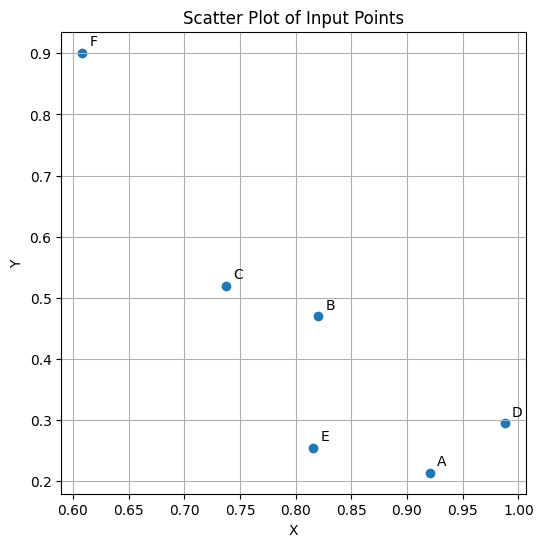

In [3]:
# A 0.920911255 0.213320996
# B 0.820434746 0.470051585
# C 0.737555362 0.519536517
# D 0.988141647 0.294653931
# E 0.81575084 0.254401699
# F 0.608505715 0.901073934


# Define the points
points = {
    "A": (0.920911255, 0.213320996),
    "B": (0.820434746, 0.470051585),
    "C": (0.737555362, 0.519536517),
    "D": (0.988141647, 0.294653931),
    "E": (0.81575084, 0.254401699),
    "F": (0.608505715, 0.901073934),
}

# Optional: separate x and y for visualization or angle conversion
labels = list(points.keys())
x_vals = np.array([points[k][0] for k in labels])
y_vals = np.array([points[k][1] for k in labels])

plt.figure(figsize=(6, 6))
plt.scatter(x_vals, y_vals)

for i, label in enumerate(labels):
    plt.annotate(
        label, (x_vals[i], y_vals[i]), textcoords="offset points", xytext=(5, 5)
    )

plt.title("Scatter Plot of Input Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

In [4]:
# Convert to quantum angles
theta_vals = (x_vals + 1) * (np.pi / 2)
phi_vals = (y_vals + 1) * (np.pi / 2)

theta_vals

array([3.01736034, 2.85953221, 2.72934558, 3.1229656 , 2.85217475,
       2.52663487])

In [5]:
# NUM_QUBITS = 3
# amps1 = 1 - 2 * np.random.rand(
#     2**NUM_QUBITS
# )  # vector of 2^3 numbers in the range [-1,1]
# amps2 = 1 - 2 * np.random.rand(2**NUM_QUBITS)
# amps1 = amps1 / np.linalg.norm(amps1)  # normalize the vector
# amps2 = amps2 / np.linalg.norm(amps2)

In [13]:
@qfunc
def main(test: Output[QBit]):

    state1 = QBit("state1")
    state2 = QBit("state2")

    # allocate(test)
    allocate(state1)
    allocate(state2)
    # prepare_amplitudes(amps1.tolist(), 0.0, state1)
    # prepare_amplitudes(amps2.tolist(), 0.0, state2)

    U(theta_vals[0], phi_vals[0], 0, 0, state1)
    U(theta_vals[1], phi_vals[1], 0, 0, state2)

    swap_test(state1, state2, test)


qprog = synthesize(main)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/2yPc1MDZaaWZoz3379pbl8x9qtA?login=True&version=0.83.0


In [9]:
res = execute(qprog)

In [11]:
res.result()

[TaggedExecutionDetails(value_type=<SavedResultValueType.ExecutionDetails: 'ExecutionDetails'>, name='result', value=ExecutionDetails(vendor_format_result={}, counts={'1': 12, '0': 2036}, counts_lsb_right=True, probabilities={}, parsed_states={'1': {'test': 1}, '0': {'test': 0}}, histogram=None, output_qubits_map={'test': (0,)}, state_vector=None, parsed_state_vector_states=None, physical_qubits_map={'test': (2,)}, num_shots=2048))]

In [ ]:
break

# A quantum “black box” for entropy calculation

In [ ]:
import numpy as np

from classiq import *

In [ ]:
W_matrix = [[0.285, 0, 0, 0], [0, 0.215, 0, 0], [0, 0, 0.072, 0], [0, 0, 0, 0.428]]

In [ ]:
v = np.array([4, 3, 1, 6])
v_sqrt = np.sqrt(v)
norm = np.sqrt(np.linalg.norm(v))
vv = v_sqrt / norm
print(vv)


exe_v = [np.sqrt(14) / 7, np.sqrt(42) / 14, np.sqrt(14) / 14, np.sqrt(21) / 7]
test = np.array(exe_v)
print(test**2)

In [ ]:
@qfunc
def PE(x: QArray[QBit]):
    pass


@qfunc
def W(x: QArray[QBit]):
    pass

In [ ]:
@qfunc
def main(s: Output[QArray[QBit]]):
    # allocate(2,s)
    prepare_amplitudes(vv, 0, s)
    hadamard_transform(s)

    # inplace_prepare_amplitudes(vv, 0, s)
    # unitary(W_matrix, 2)

In [ ]:
qprog = synthesize(main)
# show(qprog)